In [27]:
"""
TACO Dataset UNet Segmentation Model for Kaggle T4 GPU
=======================================================
This script implements a UNet model for semantic segmentation of the TACO dataset
with the top 5 classes:
    0: Cigarette
    1: Unlabeled litter  
    2: Plastic film
    3: Clear plastic bottle
    4: Other plastic

Optimized for Kaggle T4 GPU (16GB VRAM)
"""

import os
import json
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [28]:
# ======================= Configuration =======================
class Config:
    # Paths - Update these for your Kaggle environment
    ANNOTATIONS_PATH = '/kaggle/input/tacotrashdataset/data/annotations.json'  # Original TACO annotations
    META_CSV_PATH = '/kaggle/input/tacotrashdataset/meta_df.csv'  # Meta file with all annotations info
    IMAGES_ROOT = '/kaggle/input/tacotrashdataset/data'  # Root folder containing batch_* folders
    OUTPUT_DIR = '/kaggle/working'
    
    # Top 5 classes to use (from meta_df analysis)
    # Original category IDs -> New class indices (0 is background)
    TOP5_CLASSES = {
        59: 1,  # Cigarette -> 1
        58: 2,  # Unlabeled litter -> 2
        36: 3,  # Plastic film -> 3
        5:  4,   # Clear plastic bottle -> 4
        29: 5,  # Other plastic -> 5
    }
    TOP5_CLASS_NAMES = ['Background', 'Cigarette', 'Unlabeled litter', 'Plastic film', 
                        'Clear plastic bottle', 'Other plastic']
    
    # Model parameters
    IMAGE_SIZE = 512  # Optimized for T4 GPU memory
    NUM_CLASSES = 6   # 5 classes + 1 background
    IN_CHANNELS = 3
    
    # Training parameters
    BATCH_SIZE = 8    # Optimized for T4 GPU
    NUM_EPOCHS = 10  # More epochs for better convergence
    LEARNING_RATE = 3e-4  # Lower LR for stable training
    WEIGHT_DECAY = 1e-4
    
    # Data split
    TRAIN_SPLIT = 0.8
    VAL_SPLIT = 0.1
    TEST_SPLIT = 0.1
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Mixed precision 
    USE_AMP = True
    
    # Early stopping
    PATIENCE = 4  # More patience for small object learning
    
    # Checkpoint
    SAVE_BEST_MODEL = True

config = Config()

In [29]:
# ======================= Data Loading =======================
import pandas as pd

def load_and_filter_data(annotations_path, meta_csv_path, top5_classes):
    """
    Load original annotations and filter using meta_df for top 5 classes.
    
    Args:
        annotations_path: Path to original TACO annotations.json
        meta_csv_path: Path to meta_df.csv
        top5_classes: Dict mapping original category_id to new class index
    
    Returns:
        filtered_data: Dict with images, annotations, categories in COCO format
    """
    # Load meta_df to get annotation IDs for top 5 classes
    print("Loading meta_df.csv...")
    meta_df = pd.read_csv(meta_csv_path)
    
    # Filter for top 5 classes by category name
    top5_names = ['Cigarette', 'Unlabeled litter', 'Plastic film', 'Clear plastic bottle', 'Other plastic']
    filtered_meta = meta_df[meta_df['cat_name'].isin(top5_names)]
    
    print(f"Found {len(filtered_meta)} annotations for top 5 classes")
    print("Class distribution:")
    print(filtered_meta['cat_name'].value_counts())
    
    # Get annotation IDs and image IDs
    valid_ann_ids = set(filtered_meta['ann_id'].tolist())
    valid_img_ids = set(filtered_meta['img_id'].tolist())
    
    # Load original annotations
    print(f"\nLoading original annotations from {annotations_path}...")
    with open(annotations_path, 'r') as f:
        original_data = json.load(f)
    
    print(f"Original annotations: {len(original_data['annotations'])}")
    print(f"Original images: {len(original_data['images'])}")
    
    # Filter annotations by annotation ID and remap category IDs
    filtered_annotations = []
    for ann in original_data['annotations']:
        if ann['id'] in valid_ann_ids:
            original_cat_id = ann['category_id']
            if original_cat_id in top5_classes:
                # Create new annotation with remapped category_id
                new_ann = ann.copy()
                new_ann['category_id'] = top5_classes[original_cat_id] - 1  # 0-indexed for mask creation
                filtered_annotations.append(new_ann)
    
    print(f"Filtered annotations: {len(filtered_annotations)}")
    
    # Filter images to only those with valid annotations
    filtered_images = [img for img in original_data['images'] if img['id'] in valid_img_ids]
    print(f"Filtered images: {len(filtered_images)}")
    
    # Create new categories list for top 5
    new_categories = [
        {'id': 0, 'name': 'Cigarette', 'supercategory': 'Cigarette'},
        {'id': 1, 'name': 'Unlabeled litter', 'supercategory': 'Unlabeled litter'},
        {'id': 2, 'name': 'Plastic film', 'supercategory': 'Plastic bag & wrapper'},
        {'id': 3, 'name': 'Clear plastic bottle', 'supercategory': 'Bottle'},
        {'id': 4, 'name': 'Other plastic', 'supercategory': 'Other plastic'},
    ]
    
    filtered_data = {
        'images': filtered_images,
        'annotations': filtered_annotations,
        'categories': new_categories
    }
    
    return filtered_data

def create_segmentation_mask(annotations, image_info, num_classes=6):
    """
    Create segmentation mask from polygon annotations
    
    Args:
        annotations: List of annotation dicts with segmentation polygons
        image_info: Dict with image width and height
        num_classes: Number of classes including background
    
    Returns:
        mask: (H, W) numpy array with class indices
    """
    height = image_info['height']
    width = image_info['width']
    
    # Initialize mask with background (class 0)
    mask = np.zeros((height, width), dtype=np.uint8)
    
    for ann in annotations:
        category_id = ann['category_id']
        segmentation = ann['segmentation']
        
        # Convert polygon to mask
        for seg in segmentation:
            # Reshape polygon points
            pts = np.array(seg).reshape(-1, 2).astype(np.int32)
            # Fill polygon with category_id + 1 (0 is background)
            cv2.fillPoly(mask, [pts], category_id + 1)
    
    return mask

class TACOSegmentationDataset(Dataset):
    """
    TACO Dataset for Semantic Segmentation
    """
    def __init__(self, annotations_data, image_ids, images_root, transform=None, 
                 image_size=512, num_classes=6):
        self.images_root = images_root
        self.transform = transform
        self.image_size = image_size
        self.num_classes = num_classes
        
        # Create lookup dictionaries
        self.images = {img['id']: img for img in annotations_data['images']}
        self.categories = {cat['id']: cat for cat in annotations_data['categories']}
        
        # Group annotations by image_id
        self.image_annotations = defaultdict(list)
        for ann in annotations_data['annotations']:
            self.image_annotations[ann['image_id']].append(ann)
        
        # Filter to only include requested image_ids that have annotations
        self.image_ids = [img_id for img_id in image_ids 
                         if img_id in self.images and img_id in self.image_annotations]
        
        print(f"Dataset initialized with {len(self.image_ids)} images")
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.images[image_id]
        annotations = self.image_annotations[image_id]
        
        # Load image
        image_path = os.path.join(self.images_root, image_info['file_name'])
        image = cv2.imread(image_path)
        if image is None:
            # Try alternative path
            image_path = os.path.join(self.images_root, 'data', image_info['file_name'])
            image = cv2.imread(image_path)
        
        if image is None:
            # Return a blank image and mask if file not found
            image = np.zeros((self.image_size, self.image_size, 3), dtype=np.uint8)
            mask = np.zeros((self.image_size, self.image_size), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Create segmentation mask
            mask = create_segmentation_mask(annotations, image_info, self.num_classes)
        
        # Apply transforms
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask'].long()  # Ensure mask is Long tensor for CrossEntropyLoss
        else:
            # Default resize and normalize
            image = cv2.resize(image, (self.image_size, self.image_size))
            mask = cv2.resize(mask, (self.image_size, self.image_size), 
                            interpolation=cv2.INTER_NEAREST)
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()
        
        return image, mask

In [30]:
# ======================= Augmentations =======================
def get_train_transforms(image_size):
    """Get training augmentation pipeline - GENTLE to preserve small objects like cigarettes"""
    return A.Compose([
        # CRITICAL: Resize first to preserve all objects, NO random cropping
        A.LongestMaxSize(max_size=image_size),
        A.PadIfNeeded(min_height=image_size, min_width=image_size, 
                      border_mode=cv2.BORDER_CONSTANT, value=0),
        
        # Gentle geometric augmentations - NO aggressive zoom/crop
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.RandomRotate90(p=0.3),
        # Very gentle shift/scale - small objects must stay visible
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=30, p=0.5,
                          border_mode=cv2.BORDER_CONSTANT),
        
        # Color augmentations - these don't remove objects
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1),
            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1),
            A.HueSaturationValue(hue_shift_limit=30, sat_shift_limit=40, val_shift_limit=30, p=1),
        ], p=0.7),
        
        # Light noise/blur
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 30.0), p=1),
            A.GaussianBlur(blur_limit=(3, 5), p=1),
        ], p=0.2),
        
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_val_transforms(image_size):
    """Get validation/test augmentation pipeline"""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

In [31]:
# ======================= UNet Model =======================
class ConvBlock(nn.Module):
    """Double convolution block for UNet"""
    def __init__(self, in_channels, out_channels, use_bn=True):
        super().__init__()
        self.use_bn = use_bn
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_bn)
        self.bn1 = nn.BatchNorm2d(out_channels) if use_bn else nn.Identity()
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_bn)
        self.bn2 = nn.BatchNorm2d(out_channels) if use_bn else nn.Identity()
        
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(0.1)
    
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.conv2(x)))
        return x

class AttentionGate(nn.Module):
    """Attention gate for skip connections"""
    def __init__(self, gate_channels, skip_channels, inter_channels):
        super().__init__()
        self.W_gate = nn.Sequential(
            nn.Conv2d(gate_channels, inter_channels, kernel_size=1, bias=True),
            nn.BatchNorm2d(inter_channels)
        )
        self.W_skip = nn.Sequential(
            nn.Conv2d(skip_channels, inter_channels, kernel_size=1, bias=True),
            nn.BatchNorm2d(inter_channels)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, gate, skip):
        g = self.W_gate(gate)
        s = self.W_skip(skip)
        
        # Upsample gate to match skip size if needed
        if g.shape[2:] != s.shape[2:]:
            g = F.interpolate(g, size=s.shape[2:], mode='bilinear', align_corners=True)
        
        psi = self.relu(g + s)
        psi = self.psi(psi)
        return skip * psi


class UNetEncoder(nn.Module):
    """Encoder block for UNet"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        x = self.conv(x)
        p = self.pool(x)
        return x, p


class UNetDecoder(nn.Module):
    """Decoder block for UNet with attention"""
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.attention = AttentionGate(out_channels, skip_channels, skip_channels // 2)
        self.conv = ConvBlock(out_channels + skip_channels, out_channels)
    
    def forward(self, x, skip):
        x = self.upconv(x)
        
        # Handle size mismatch
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        
        # Apply attention to skip connection
        skip = self.attention(x, skip)
        
        # Concatenate and process
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

class UNet(nn.Module):
    """
    UNet with Attention Gates for Semantic Segmentation
    
    Features:
    - Encoder-decoder architecture with skip connections
    - Attention gates for better feature selection
    - Dropout for regularization
    - BatchNorm for stable training
    """
    def __init__(self, in_channels=3, num_classes=6, features=[64, 128, 256, 512, 1024]):
        super().__init__()
        self.features = features
        
        # Encoder path
        self.enc1 = UNetEncoder(in_channels, features[0])      # 3 -> 64
        self.enc2 = UNetEncoder(features[0], features[1])      # 64 -> 128
        self.enc3 = UNetEncoder(features[1], features[2])      # 128 -> 256
        self.enc4 = UNetEncoder(features[2], features[3])      # 256 -> 512
        
        # Bottleneck
        self.bottleneck = ConvBlock(features[3], features[4])  # 512 -> 1024
        
        # Decoder path
        self.dec4 = UNetDecoder(features[4], features[3], features[3])  # 1024 -> 512
        self.dec3 = UNetDecoder(features[3], features[2], features[2])  # 512 -> 256
        self.dec2 = UNetDecoder(features[2], features[1], features[1])  # 256 -> 128
        self.dec1 = UNetDecoder(features[1], features[0], features[0])  # 128 -> 64
        
        # Final convolution
        self.final_conv = nn.Conv2d(features[0], num_classes, kernel_size=1)
    
    def forward(self, x):
        # Encoder
        s1, p1 = self.enc1(x)   # s1: 64, p1: 64 (pooled)
        s2, p2 = self.enc2(p1)  # s2: 128, p2: 128 (pooled)
        s3, p3 = self.enc3(p2)  # s3: 256, p3: 256 (pooled)
        s4, p4 = self.enc4(p3)  # s4: 512, p4: 512 (pooled)
        
        # Bottleneck
        b = self.bottleneck(p4)  # b: 1024
        
        # Decoder
        d4 = self.dec4(b, s4)   # 1024 + 512 -> 512
        d3 = self.dec3(d4, s3)  # 512 + 256 -> 256
        d2 = self.dec2(d3, s2)  # 256 + 128 -> 128
        d1 = self.dec1(d2, s1)  # 128 + 64 -> 64
        
        return self.final_conv(d1)

In [32]:
# ======================= Loss Functions =======================
class DiceLoss(nn.Module):
    """Dice loss for segmentation - focuses on foreground classes"""
    def __init__(self, smooth=1e-6, ignore_background=True):
        super().__init__()
        self.smooth = smooth
        self.ignore_background = ignore_background
    
    def forward(self, logits, targets):
        # Apply softmax
        probs = F.softmax(logits, dim=1)
        
        # One-hot encode targets
        num_classes = logits.shape[1]
        targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
        
        # Calculate Dice coefficient per class
        intersection = (probs * targets_onehot).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets_onehot.sum(dim=(2, 3))
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        
        if self.ignore_background:
            # Only compute loss on foreground classes (skip class 0)
            dice = dice[:, 1:]  # Shape: (B, num_classes-1)
        
        return 1 - dice.mean()


class FocalLoss(nn.Module):
    """Focal loss with class weights to handle extreme class imbalance"""
    def __init__(self, alpha=None, gamma=3, class_weights=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma  # Higher gamma focuses more on hard examples
        self.class_weights = class_weights
    
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.class_weights, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


class TverskyLoss(nn.Module):
    """
    Tversky Loss - generalization of Dice that allows control over FP vs FN penalty.
    Setting alpha > beta penalizes false negatives more (better for small objects).
    Now with per-class weighting to boost small object classes.
    """
    def __init__(self, alpha=0.8, beta=0.2, smooth=1e-6, ignore_background=True):
        super().__init__()
        self.alpha = alpha  # Weight for false negatives (higher = penalize missing objects more)
        self.beta = beta    # Weight for false positives
        self.smooth = smooth
        self.ignore_background = ignore_background
        # Per-class weights: [Cigarette, Unlabeled, Plastic film, Bottle, Other plastic]
        self.class_boost = torch.tensor([5.0, 2.0, 1.0, 1.0, 2.5])  # Boost small object classes
    
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        num_classes = logits.shape[1]
        targets_onehot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
        
        # True positives, false positives, false negatives
        tp = (probs * targets_onehot).sum(dim=(2, 3))
        fp = (probs * (1 - targets_onehot)).sum(dim=(2, 3))
        fn = ((1 - probs) * targets_onehot).sum(dim=(2, 3))
        
        tversky = (tp + self.smooth) / (tp + self.alpha * fn + self.beta * fp + self.smooth)
        
        if self.ignore_background:
            tversky = tversky[:, 1:]  # Shape: (B, 5)
            # Apply per-class weighting
            class_boost = self.class_boost.to(logits.device)
            weighted_tversky = tversky * class_boost
            return 1 - weighted_tversky.mean()
        
        return 1 - tversky.mean()


class BoundaryLoss(nn.Module):
    """Boundary-aware loss to improve edge detection of small objects"""
    def __init__(self, theta=5):
        super().__init__()
        self.theta = theta
        # Sobel kernels for edge detection
        self.sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        self.sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
    
    def get_boundary(self, mask):
        """Extract boundary from mask using Sobel operator"""
        # mask: (B, H, W)
        mask = mask.float().unsqueeze(1)  # (B, 1, H, W)
        
        sobel_x = self.sobel_x.to(mask.device)
        sobel_y = self.sobel_y.to(mask.device)
        
        edge_x = F.conv2d(mask, sobel_x, padding=1)
        edge_y = F.conv2d(mask, sobel_y, padding=1)
        
        edge = torch.sqrt(edge_x ** 2 + edge_y ** 2 + 1e-6)
        edge = (edge > 0.5).float()
        
        return edge.squeeze(1)  # (B, H, W)
    
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        pred_mask = torch.argmax(probs, dim=1)
        
        # Get boundaries
        pred_boundary = self.get_boundary(pred_mask.float())
        target_boundary = self.get_boundary(targets.float())
        
        # Boundary loss
        loss = F.binary_cross_entropy_with_logits(
            pred_boundary, target_boundary, reduction='mean'
        )
        
        return loss


class CombinedLoss(nn.Module):
    """Combined loss optimized for small object segmentation with OHEM"""
    def __init__(self, class_weights=None, focal_gamma=4):
        super().__init__()
        self.class_weights = class_weights
        
        # Weighted CE for overall learning
        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)
        
        # Focal loss with very high gamma for hard examples
        self.focal_loss = FocalLoss(gamma=focal_gamma, class_weights=class_weights)
        
        # Tversky loss with higher alpha to heavily penalize false negatives
        self.tversky_loss = TverskyLoss(alpha=0.8, beta=0.2, ignore_background=True)
        
        # Dice loss on foreground only
        self.dice_loss = DiceLoss(ignore_background=True)
    
    def forward(self, logits, targets):
        ce = self.ce_loss(logits, targets)
        focal = self.focal_loss(logits, targets)
        tversky = self.tversky_loss(logits, targets)
        dice = self.dice_loss(logits, targets)
        
        # Online Hard Example Mining - focus on pixels where we're wrong
        with torch.no_grad():
            preds = torch.argmax(logits, dim=1)
            # Find foreground pixels that are misclassified
            foreground_mask = targets > 0
            wrong_mask = (preds != targets) & foreground_mask
            
        # Extra penalty for misclassified foreground
        if wrong_mask.sum() > 0:
            hard_ce = F.cross_entropy(logits, targets, weight=self.class_weights, reduction='none')
            hard_loss = (hard_ce * wrong_mask.float()).sum() / (wrong_mask.sum() + 1e-6)
        else:
            hard_loss = torch.tensor(0.0, device=logits.device)
        
        # Combine losses - heavily emphasize foreground detection
        total_loss = 0.1 * ce + 0.25 * focal + 0.35 * tversky + 0.2 * dice + 0.1 * hard_loss
        
        return total_loss

In [33]:
# ======================= Metrics =======================
class SegmentationMetrics:
    """Calculate segmentation metrics"""
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.reset()
    
    def reset(self):
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes))
    
    def update(self, preds, targets):
        preds = preds.flatten()
        targets = targets.flatten()
        
        for t, p in zip(targets, preds):
            self.confusion_matrix[t, p] += 1
    
    def get_iou(self):
        """Calculate IoU for each class"""
        iou = np.zeros(self.num_classes)
        for i in range(self.num_classes):
            tp = self.confusion_matrix[i, i]
            fp = self.confusion_matrix[:, i].sum() - tp
            fn = self.confusion_matrix[i, :].sum() - tp
            
            if tp + fp + fn > 0:
                iou[i] = tp / (tp + fp + fn)
        return iou
    
    def get_dice(self):
        """Calculate Dice coefficient for each class"""
        dice = np.zeros(self.num_classes)
        for i in range(self.num_classes):
            tp = self.confusion_matrix[i, i]
            fp = self.confusion_matrix[:, i].sum() - tp
            fn = self.confusion_matrix[i, :].sum() - tp
            
            if 2 * tp + fp + fn > 0:
                dice[i] = 2 * tp / (2 * tp + fp + fn)
        return dice
    
    def get_pixel_accuracy(self):
        """Calculate pixel accuracy"""
        correct = np.diag(self.confusion_matrix).sum()
        total = self.confusion_matrix.sum()
        return correct / total if total > 0 else 0

In [34]:
# ======================= Training Functions =======================
def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device, epoch):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    metrics = SegmentationMetrics(config.NUM_CLASSES)
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1} [Train]')
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        with autocast(enabled=config.USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        
        # Update metrics
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        targets = masks.cpu().numpy()
        metrics.update(preds, targets)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(dataloader)
    iou = metrics.get_iou()
    dice = metrics.get_dice()
    pixel_acc = metrics.get_pixel_accuracy()
    
    return epoch_loss, iou.mean(), dice.mean(), pixel_acc

@torch.no_grad()
def validate(model, dataloader, criterion, device, epoch):
    """Validate model"""
    model.eval()
    running_loss = 0.0
    metrics = SegmentationMetrics(config.NUM_CLASSES)
    
    pbar = tqdm(dataloader, desc=f'Epoch {epoch+1} [Val]')
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        with autocast(enabled=config.USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        running_loss += loss.item()
        
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        targets = masks.cpu().numpy()
        metrics.update(preds, targets)
    
    epoch_loss = running_loss / len(dataloader)
    iou = metrics.get_iou()
    dice = metrics.get_dice()
    pixel_acc = metrics.get_pixel_accuracy()
    
    return epoch_loss, iou.mean(), dice.mean(), pixel_acc, iou, dice

In [35]:
# ======================= Visualization =======================
def visualize_predictions(model, dataloader, device, num_samples=4, save_path=None):
    """Visualize model predictions"""
    model.eval()
    
    # Get samples
    images, masks = next(iter(dataloader))
    images = images[:num_samples].to(device)
    masks = masks[:num_samples]
    
    with torch.no_grad():
        with autocast(enabled=config.USE_AMP):
            outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu()
    
    # Denormalize images
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    images = images.cpu() * std + mean
    images = images.clamp(0, 1)
    
    # Create color map
    colors = np.array([
        [0, 0, 0],        # Background - black
        [255, 0, 0],      # Cigarette - red
        [0, 255, 0],      # Unlabeled litter - green
        [0, 0, 255],      # Plastic film - blue
        [255, 255, 0],    # Clear plastic bottle - yellow
        [255, 0, 255],    # Other plastic - magenta
    ], dtype=np.uint8)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    
    for i in range(num_samples):
        # Original image
        img = images[i].permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')
        
        # Ground truth
        gt_mask = masks[i].numpy()
        gt_colored = colors[gt_mask]
        axes[i, 1].imshow(gt_colored)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Prediction
        pred_mask = preds[i].numpy()
        pred_colored = colors[pred_mask]
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title('Prediction')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved visualization to {save_path}")
    
    plt.show()

def plot_training_history(history, save_path=None):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train')
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Validation')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training & Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # mIoU
    axes[0, 1].plot(epochs, history['train_iou'], 'b-', label='Train')
    axes[0, 1].plot(epochs, history['val_iou'], 'r-', label='Validation')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('mIoU')
    axes[0, 1].set_title('Mean IoU')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Dice
    axes[1, 0].plot(epochs, history['train_dice'], 'b-', label='Train')
    axes[1, 0].plot(epochs, history['val_dice'], 'r-', label='Validation')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Dice Score')
    axes[1, 0].set_title('Mean Dice Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # Pixel Accuracy
    axes[1, 1].plot(epochs, history['train_acc'], 'b-', label='Train')
    axes[1, 1].plot(epochs, history['val_acc'], 'r-', label='Validation')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Pixel Accuracy')
    axes[1, 1].set_title('Pixel Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved training history to {save_path}")
    
    plt.show()

Using device: cuda
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.83 GB

Loading and filtering data for top 5 classes...
Loading meta_df.csv...
Found 2193 annotations for top 5 classes
Class distribution:
cat_name
Cigarette               667
Unlabeled litter        517
Plastic film            451
Clear plastic bottle    285
Other plastic           273
Name: count, dtype: int64

Loading original annotations from /kaggle/input/tacotrashdataset/data/annotations.json...
Original annotations: 4784
Original images: 1500
Filtered annotations: 2193
Filtered images: 861

Total images with top 5 class annotations: 861

Filtered Classes (Top 5):
  0: Background
  1: Cigarette
  2: Unlabeled litter
  3: Plastic film
  4: Clear plastic bottle
  5: Other plastic

Annotations per class:
  Cigarette (0): 667
  Unlabeled litter (1): 517
  Plastic film (2): 451
  Clear plastic bottle (3): 285
  Other plastic (4): 273

Data split:
  Train: 688 images
  Validation: 86 images
  Test: 87 images
Dataset i

Epoch 1 [Val]: 100%|██████████| 11/11 [00:17<00:00,  1.56s/it]



Epoch 1/10
  Train - Loss: 0.7555, mIoU: 0.0882, Dice: 0.1200, Acc: 0.5015
  Val   - Loss: 0.7383, mIoU: 0.0722, Dice: 0.1069, Acc: 0.3962

  Per-class IoU:
    Background: IoU=0.3941, Dice=0.5654
    Cigarette: IoU=0.0002, Dice=0.0004
    Unlabeled litter: IoU=0.0002, Dice=0.0004
    Plastic film: IoU=0.0328, Dice=0.0636
    Clear plastic bottle: IoU=0.0045, Dice=0.0090
    Other plastic: IoU=0.0014, Dice=0.0029
  ✓ Saved best model (mIoU: 0.0722)


Epoch 2 [Val]: 100%|██████████| 11/11 [00:17<00:00,  1.56s/it]



Epoch 2/10
  Train - Loss: 0.7430, mIoU: 0.0929, Dice: 0.1256, Acc: 0.5221
  Val   - Loss: 0.7251, mIoU: 0.0690, Dice: 0.1035, Acc: 0.3784

  Per-class IoU:
    Background: IoU=0.3760, Dice=0.5465
    Cigarette: IoU=0.0002, Dice=0.0003
    Unlabeled litter: IoU=0.0002, Dice=0.0004
    Plastic film: IoU=0.0256, Dice=0.0499
    Clear plastic bottle: IoU=0.0108, Dice=0.0215
    Other plastic: IoU=0.0012, Dice=0.0023


...


Epoch 4/10
  Train - Loss: 0.7324, mIoU: 0.0850, Dice: 0.1186, Acc: 0.4764
  Val   - Loss: 0.7214, mIoU: 0.0610, Dice: 0.0940, Acc: 0.3371

  Per-class IoU:
    Background: IoU=0.3325, Dice=0.4991
    Cigarette: IoU=0.0001, Dice=0.0002
    Unlabeled litter: IoU=0.0002, Dice=0.0004
    Plastic film: IoU=0.0258, Dice=0.0503
    Clear plastic bottle: IoU=0.0060, Dice=0.0119
    Other plastic: IoU=0.0012, Dice=0.0023


Epoch 5 [Val]: 100%|██████████| 11/11 [00:17<00:00,  1.56s/it]



Epoch 5/10
  Train - Loss: 0.7279, mIoU: 0.0831, Dice: 0.1172, Acc: 0.4625
  Val   - Loss: 0.7197, mIoU: 0.0570, Dice: 0.0897, Acc: 0.3129

  Per-class IoU:
    Background: IoU=0.3075, Dice=0.4704
    Cigarette: IoU=0.0002, Dice=0.0003
    Unlabeled litter: IoU=0.0002, Dice=0.0004
    Plastic film: IoU=0.0227, Dice=0.0444
    Clear plastic bottle: IoU=0.0106, Dice=0.0210
    Other plastic: IoU=0.0009, Dice=0.0017

Early stopping triggered after 5 epochs

Training Complete!
Best validation mIoU: 0.0722

Evaluating on Test Set


Epoch 1 [Val]: 100%|██████████| 11/11 [00:17<00:00,  1.59s/it]



Test Results:
  Loss: 0.7442
  mIoU: 0.0742
  Dice: 0.1097
  Pixel Accuracy: 0.4018

Per-class Test Results:
  Background: IoU=0.4014, Dice=0.5729
  Cigarette: IoU=0.0005, Dice=0.0009
  Unlabeled litter: IoU=0.0021, Dice=0.0041
  Plastic film: IoU=0.0319, Dice=0.0618
  Clear plastic bottle: IoU=0.0083, Dice=0.0165
  Other plastic: IoU=0.0009, Dice=0.0019
Saved training history to /kaggle/working/training_history.png


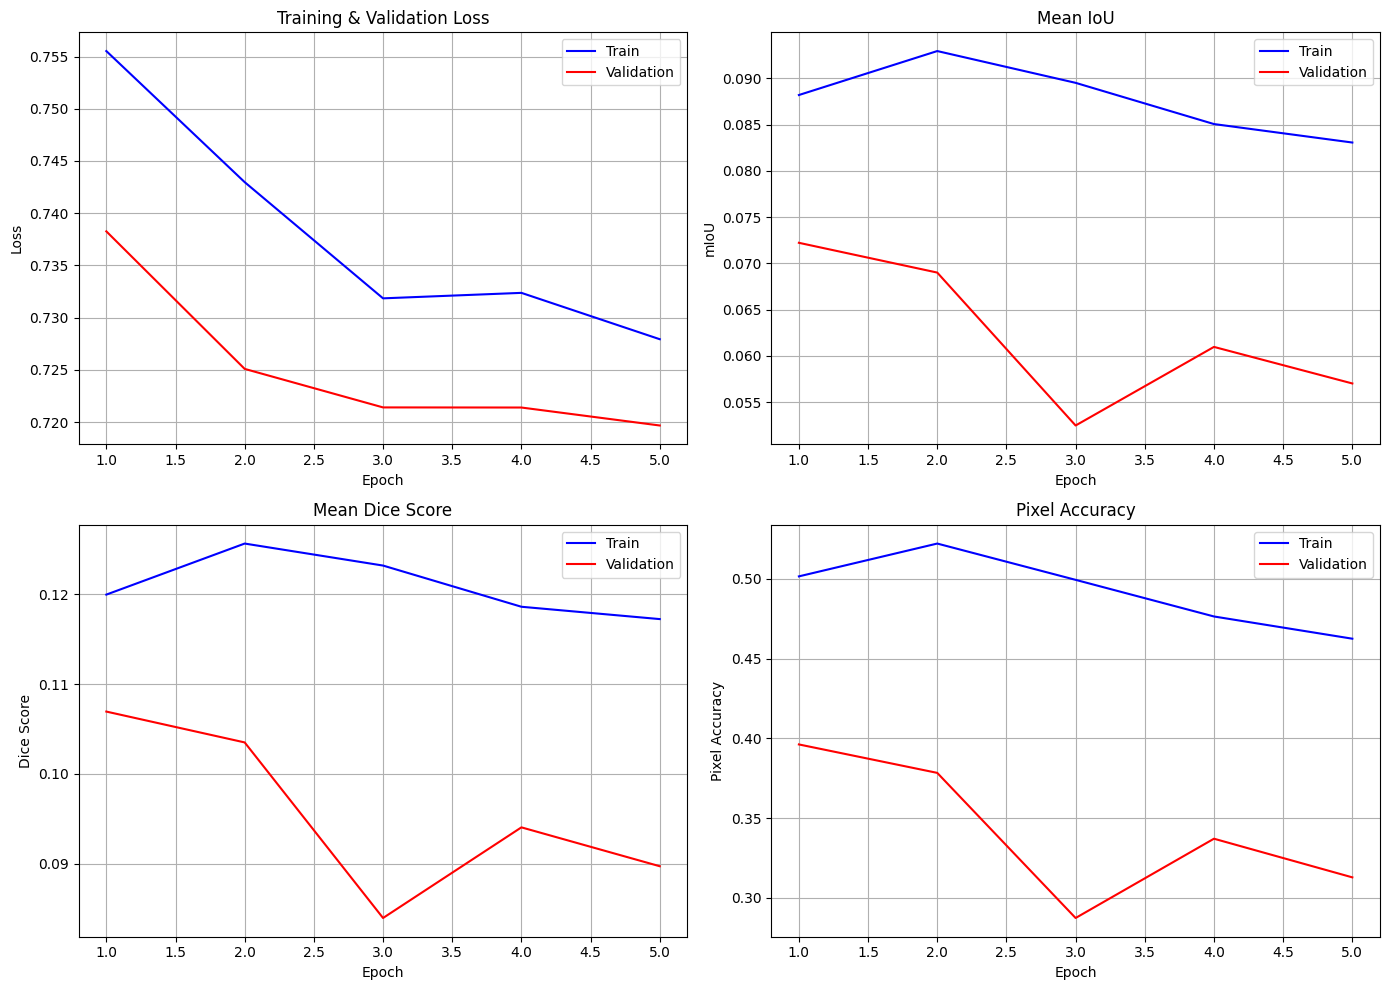

Saved visualization to /kaggle/working/predictions.png


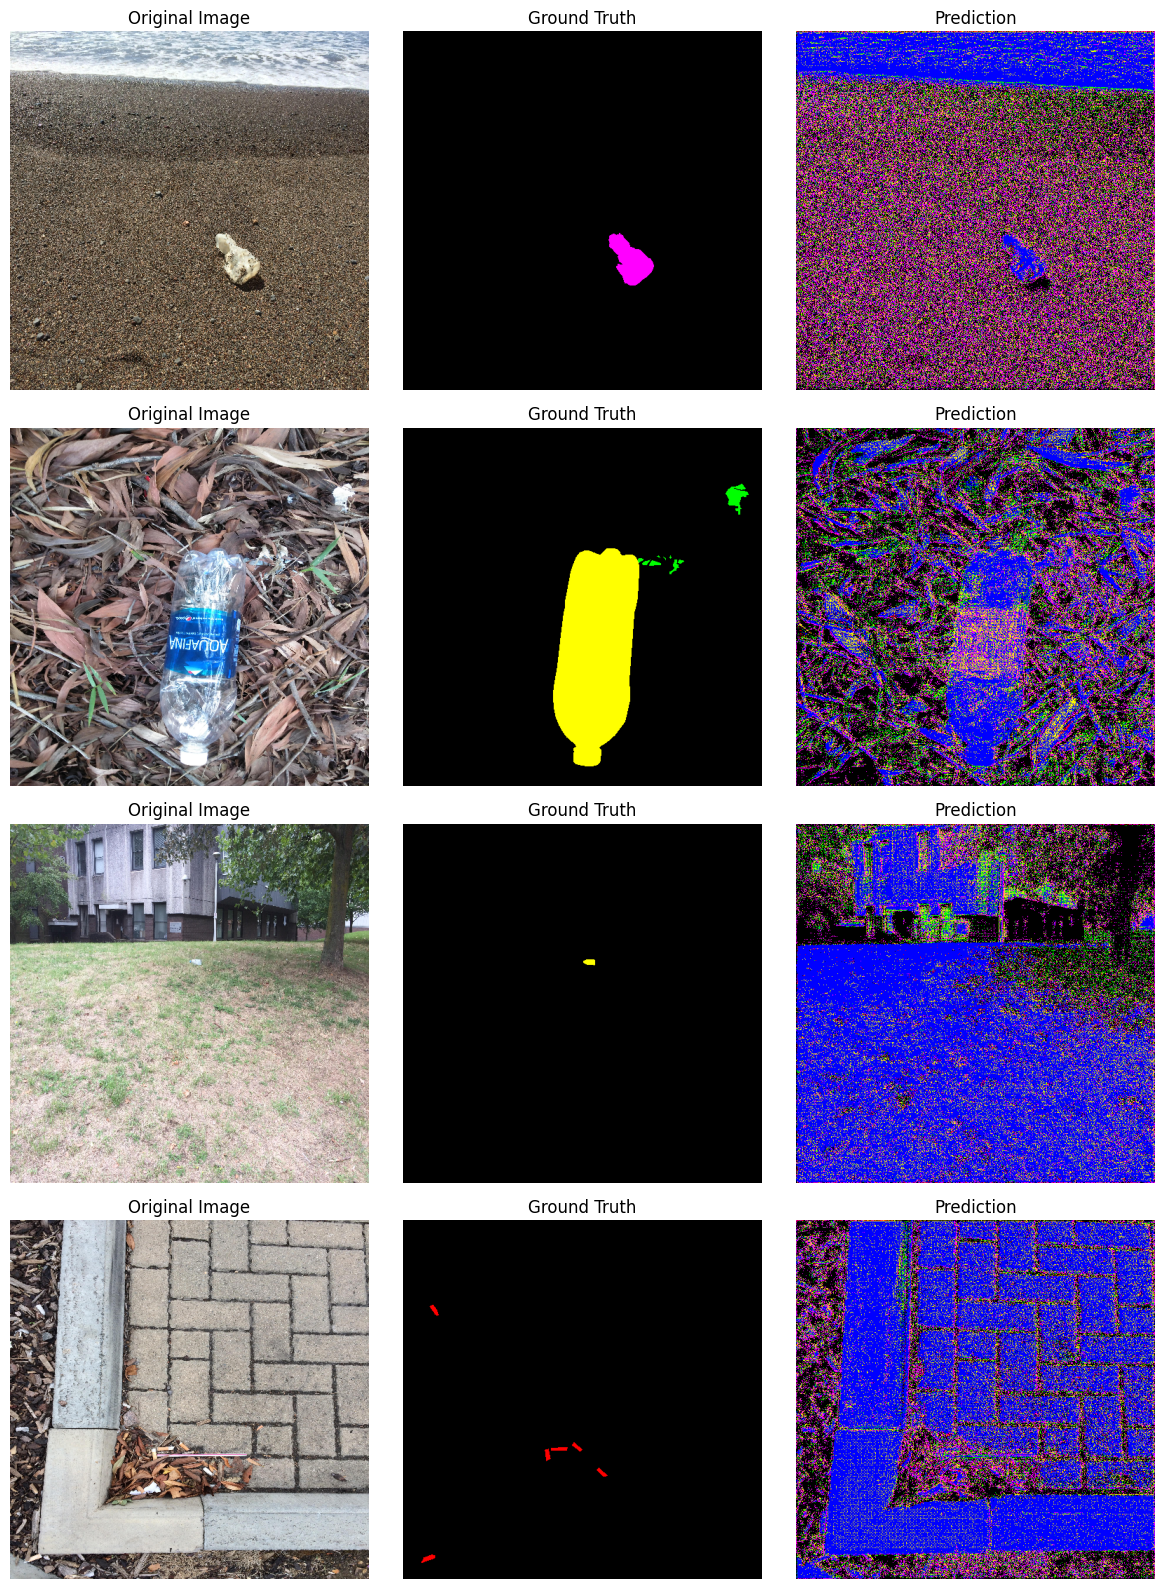


Saved final model to /kaggle/working/final_model.pth


In [36]:
# ======================= Main Training Function =======================
def main():
    print(f"Using device: {config.DEVICE}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
    # Load and filter annotations using meta_df for top 5 classes
    print("\n" + "="*60)
    print("Loading and filtering data for top 5 classes...")
    print("="*60)
    annotations_data = load_and_filter_data(
        config.ANNOTATIONS_PATH, 
        config.META_CSV_PATH, 
        config.TOP5_CLASSES
    )
    
    # Get all image IDs that have annotations
    image_ids_with_annotations = list(set(
        ann['image_id'] for ann in annotations_data['annotations']
    ))
    print(f"\nTotal images with top 5 class annotations: {len(image_ids_with_annotations)}")
    
    # Print class information
    print("\nFiltered Classes (Top 5):")
    for i, name in enumerate(config.TOP5_CLASS_NAMES):
        print(f"  {i}: {name}")
    
    # Count annotations per class (using remapped IDs)
    class_counts = defaultdict(int)
    for ann in annotations_data['annotations']:
        class_counts[ann['category_id']] += 1
    
    print("\nAnnotations per class:")
    for cat_id in sorted(class_counts.keys()):
        # cat_id is 0-indexed (0-4), class name index is cat_id + 1 (1-5 for foreground)
        print(f"  {config.TOP5_CLASS_NAMES[cat_id + 1]} ({cat_id}): {class_counts[cat_id]}")
    
    # Shuffle and split data
    random.shuffle(image_ids_with_annotations)
    
    n_total = len(image_ids_with_annotations)
    n_train = int(n_total * config.TRAIN_SPLIT)
    n_val = int(n_total * config.VAL_SPLIT)
    
    train_ids = image_ids_with_annotations[:n_train]
    val_ids = image_ids_with_annotations[n_train:n_train + n_val]
    test_ids = image_ids_with_annotations[n_train + n_val:]
    
    print(f"\nData split:")
    print(f"  Train: {len(train_ids)} images")
    print(f"  Validation: {len(val_ids)} images")
    print(f"  Test: {len(test_ids)} images")
    
    # Create datasets
    train_dataset = TACOSegmentationDataset(
        annotations_data, train_ids, config.IMAGES_ROOT,
        transform=get_train_transforms(config.IMAGE_SIZE),
        image_size=config.IMAGE_SIZE,
        num_classes=config.NUM_CLASSES
    )
    
    val_dataset = TACOSegmentationDataset(
        annotations_data, val_ids, config.IMAGES_ROOT,
        transform=get_val_transforms(config.IMAGE_SIZE),
        image_size=config.IMAGE_SIZE,
        num_classes=config.NUM_CLASSES
    )
    
    test_dataset = TACOSegmentationDataset(
        annotations_data, test_ids, config.IMAGES_ROOT,
        transform=get_val_transforms(config.IMAGE_SIZE),
        image_size=config.IMAGE_SIZE,
        num_classes=config.NUM_CLASSES
    )
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    
    # Calculate VERY aggressive class weights for loss function
    # Background dominates ~97% of pixels, so we need extreme weighting
    total_annotations = sum(class_counts.values())
    class_weights = torch.zeros(config.NUM_CLASSES)
    
    # Near-zero weight for background (it dominates pixel-wise)
    class_weights[0] = 0.005  # Reduced from 0.02
    
    # Very high weights for foreground classes
    for cat_id, count in class_counts.items():
        # Use full inverse frequency for maximum effect
        class_weights[cat_id + 1] = total_annotations / count
    
    # Normalize
    class_weights = class_weights / class_weights.sum()
    
    # AGGRESSIVELY boost small object classes
    # Class indices: 0=BG, 1=Cigarette, 2=Unlabeled, 3=Plastic film, 4=Bottle, 5=Other plastic
    class_weights[1] *= 5.0  # Cigarette - extremely small, needs huge boost
    class_weights[5] *= 3.0  # Other plastic - often small
    class_weights[2] *= 2.5  # Unlabeled litter - variable size
    class_weights[3] *= 1.5  # Plastic film
    class_weights[4] *= 1.5  # Bottle
    
    # Re-normalize after boosting
    class_weights = class_weights / class_weights.sum()
    class_weights = class_weights.to(config.DEVICE)
    
    print(f"\nClass weights (optimized for small objects):")
    for i, (name, weight) in enumerate(zip(config.TOP5_CLASS_NAMES, class_weights)):
        print(f"  {name}: {weight:.4f}")
    
    # Initialize model
    model = UNet(
        in_channels=config.IN_CHANNELS,
        num_classes=config.NUM_CLASSES,
        features=[64, 128, 256, 512, 1024]
    ).to(config.DEVICE)
    
    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters:")
    print(f"  Total: {total_params:,}")
    print(f"  Trainable: {trainable_params:,}")
    
    # Loss function - optimized for small object segmentation
    criterion = CombinedLoss(
        class_weights=class_weights,
        focal_gamma=4  # Even higher gamma for extreme class imbalance
    )
    
    # Optimizer
    optimizer = AdamW(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY
    )
    
    # Learning rate scheduler
    scheduler = OneCycleLR(
        optimizer,
        max_lr=config.LEARNING_RATE,
        epochs=config.NUM_EPOCHS,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        anneal_strategy='cos'
    )
    
    # Mixed precision scaler
    scaler = GradScaler(enabled=config.USE_AMP)
    
    # Training history
    history = {
        'train_loss': [], 'val_loss': [],
        'train_iou': [], 'val_iou': [],
        'train_dice': [], 'val_dice': [],
        'train_acc': [], 'val_acc': []
    }
    
    best_val_iou = 0.0
    patience_counter = 0
    
    print("\n" + "="*60)
    print("Starting Training")
    print("="*60 + "\n")
    
    for epoch in range(config.NUM_EPOCHS):
        # Train
        train_loss, train_iou, train_dice, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, config.DEVICE, epoch
        )
        
        # Update scheduler
        # Note: OneCycleLR updates per batch, so we don't need to step here
        
        # Validate
        val_loss, val_iou, val_dice, val_acc, class_iou, class_dice = validate(
            model, val_loader, criterion, config.DEVICE, epoch
        )
        
        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_iou'].append(train_iou)
        history['val_iou'].append(val_iou)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        # Print epoch summary
        print(f"\nEpoch {epoch+1}/{config.NUM_EPOCHS}")
        print(f"  Train - Loss: {train_loss:.4f}, mIoU: {train_iou:.4f}, Dice: {train_dice:.4f}, Acc: {train_acc:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, mIoU: {val_iou:.4f}, Dice: {val_dice:.4f}, Acc: {val_acc:.4f}")
        
        # Print per-class metrics
        print(f"\n  Per-class IoU:")
        for i, name in enumerate(config.TOP5_CLASS_NAMES):
            print(f"    {name}: IoU={class_iou[i]:.4f}, Dice={class_dice[i]:.4f}")
        
        # Save best model
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            patience_counter = 0
            
            if config.SAVE_BEST_MODEL:
                checkpoint_path = os.path.join(config.OUTPUT_DIR, 'best_model.pth')
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_iou': val_iou,
                    'val_dice': val_dice,
                    'class_iou': class_iou,
                    'class_dice': class_dice,
                    'history': history
                }, checkpoint_path)
                print(f"  ✓ Saved best model (mIoU: {val_iou:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= config.PATIENCE:
                print(f"\nEarly stopping triggered after {epoch+1} epochs")
                break
    
    print("\n" + "="*60)
    print("Training Complete!")
    print("="*60)
    print(f"Best validation mIoU: {best_val_iou:.4f}")
    
    # Load best model for evaluation
    if config.SAVE_BEST_MODEL:
        checkpoint = torch.load(os.path.join(config.OUTPUT_DIR, 'best_model.pth'), weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
    
    # Test set evaluation
    print("\n" + "="*60)
    print("Evaluating on Test Set")
    print("="*60)
    
    test_loss, test_iou, test_dice, test_acc, test_class_iou, test_class_dice = validate(
        model, test_loader, criterion, config.DEVICE, 0
    )
    
    print(f"\nTest Results:")
    print(f"  Loss: {test_loss:.4f}")
    print(f"  mIoU: {test_iou:.4f}")
    print(f"  Dice: {test_dice:.4f}")
    print(f"  Pixel Accuracy: {test_acc:.4f}")
    
    print(f"\nPer-class Test Results:")
    for i, name in enumerate(config.TOP5_CLASS_NAMES):
        print(f"  {name}: IoU={test_class_iou[i]:.4f}, Dice={test_class_dice[i]:.4f}")
    
    # Save visualizations
    plot_training_history(history, os.path.join(config.OUTPUT_DIR, 'training_history.png'))
    visualize_predictions(model, test_loader, config.DEVICE, num_samples=4,
                         save_path=os.path.join(config.OUTPUT_DIR, 'predictions.png'))
    
    # Save final model
    final_model_path = os.path.join(config.OUTPUT_DIR, 'final_model.pth')
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': {
            'image_size': config.IMAGE_SIZE,
            'num_classes': config.NUM_CLASSES,
            'features': [64, 128, 256, 512, 1024]
        },
        'class_names': config.TOP5_CLASS_NAMES,
        'test_metrics': {
            'loss': test_loss,
            'miou': test_iou,
            'dice': test_dice,
            'pixel_acc': test_acc,
            'class_iou': test_class_iou.tolist(),
            'class_dice': test_class_dice.tolist()
        }
    }, final_model_path)
    print(f"\nSaved final model to {final_model_path}")

if __name__ == '__main__':
    main()